# Task 1: Rotated MNIST

In this task you will use MNIST dataset. The images are 28x28 and they are **rotated** by an angle from the range (-100, 100).  
You are given a pipeline that trains a multi-head convolutional neural network on this dataset. The first head of the model performs a digit classification and the second head tries to predict the angle that the digit was rotated by.

Your task is to:
1. **(5 pts)** Implement CNN with classification and regression heads.
2. **(3 pts)** Implement the model's loss - select appropriate loss functions for both heads and combine them into final loss of the model.
3. **(3 pts)** Check the model's predictions on the test data and find for which classes the model achieves the best/worst performance both for classification and regression. Then, write a short explanation for the observed model behavior (why does the model have a problem with particular classes?).

Hints:
- You don't need to create a very sophisticated model - a few convolutions for CNN and a few linear layers for heads should be enough. After a few epochs the model should achieve classification accuracy above 90% and regression MAE below 18 on a test dataset.
- When training multi-head models it is usually good to scale losses from particular heads so that they have similar contribution towards the final loss.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from PIL import Image

In [2]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv_blocks = torch.nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(8, 16, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=1, padding=1), nn.ReLU(),
            nn.Conv2d(32, 16, 3, stride=1, padding=1), nn.ReLU(),
            nn.Flatten(),
        )
        self.classification_head = torch.nn.Sequential(
            nn.Linear(16*28*28, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 10),
            nn.LogSoftmax(dim=1),
        )
        self.regression_head = torch.nn.Sequential(
            nn.Linear(16*28*28, 256), nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        ################## TODO ####################
        # Subtask 1: Implement forward
        # print(x.shape)
        # for i in self.conv_blocks:
        #     print(i)
        #     x = i(x)
        #     print(x.shape)
        # log_probs = x.clone()
        # for i in self.classification_head:
        #     print(i)
        #     log_probs = i(log_probs)
        #     print(log_probs.shape)
        convs = self.conv_blocks(x)
        log_probs = self.classification_head(convs)
        angle = self.regression_head(convs)
        angle = angle.flatten()
        return log_probs, angle


def train(model, device, train_loader, optimizer, epoch, log_interval):
    model.train()
    for batch_idx, (data, (target_digit, target_angle)) in enumerate(train_loader):
        data = data.to(device)
        target_digit, target_angle = target_digit.to(device), target_angle.to(device)
        optimizer.zero_grad()
        log_probs, angle = model(data)
        ################## TODO ####################
        # Subtask 2: Implement classification and regression loss, then combine them into
        # final model loss
        classification_loss = F.nll_loss(log_probs, target_digit)
        regression_loss = F.mse_loss(angle, target_angle)
        loss = 0.999 * classification_loss + 0.001 * regression_loss
        loss.backward()
        optimizer.step()
        if (batch_idx + 1) % log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, (batch_idx + 1) * len(data), len(train_loader.dataset),
                100. * (batch_idx + 1) / len(train_loader), loss.item()
            ))


def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    abs_error = 0
    with torch.no_grad():
        for data, (target_digit, target_angle) in test_loader:
            data = data.to(device)
            target_digit, target_angle = target_digit.to(device), target_angle.to(device)
            log_probs, angle = model(data)
            ################## TODO ####################
            # Subtask 2: Implement classification and regression loss, then combine them into
            # final model loss (use the same loss as for training)
            # Hint: pass reduction='sum' to loss functions to output loss correctly when logging
            classification_loss = F.nll_loss(log_probs, target_digit)
            regression_loss = F.mse_loss(angle, target_angle)
            test_loss += 0.999 * classification_loss + 0.001 * regression_loss
            
            pred_digit = log_probs.argmax(dim=1, keepdim=True)
            correct += pred_digit.eq(target_digit.view_as(pred_digit)).sum().item()
            abs_error += (target_angle - angle).abs().sum()

    test_loss /= len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Classification accuracy: {}/{} ({:.0f}%), Regression MAE: {:.2f}\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset),
        abs_error / len(test_loader.dataset)
    ))

In [3]:
batch_size = 256
test_batch_size = 1000
epochs = 5
lr = 3e-3
seed = 1
log_interval = 50
use_cuda = torch.cuda.is_available()

In [4]:
torch.manual_seed(seed)
device = torch.device("cuda" if use_cuda else "cpu")

train_kwargs = {'batch_size': batch_size}
test_kwargs = {'batch_size': test_batch_size}
if use_cuda:
    cuda_kwargs = {
        'num_workers': 1,
        'pin_memory': True,
        'shuffle': True
    }
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

In [5]:
class MNISTWithRotations(datasets.MNIST):
    def __init__(self, *args, transform=None, target_transform=None, **kwargs):
        super(MNISTWithRotations, self).__init__(*args, **kwargs)
        self.rotation_angles = (torch.rand(len(self.data)) - 0.5) * 2 * 100
        self.is_img_transforemed = [False] * len(self.data)
        self.transformed_data = torch.zeros(*self.data.shape)

    def __getitem__(self, idx):
        if not self.is_img_transforemed[idx]:
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Lambda(
                    lambda x: transforms.functional.rotate(x, self.rotation_angles[idx].item())
                ),
                transforms.Normalize((0.1307,), (0.3081,)),
            ])
            img = Image.fromarray(self.data[idx].numpy(), mode="L")
            self.transformed_data[idx] = transform(img)
            self.is_img_transforemed[idx] = True

        img = self.transformed_data[idx].unsqueeze(0)
        target_digit = int(self.targets[idx])
        target_angle = self.rotation_angles[idx]
        return img, (target_digit, target_angle)

In [6]:
train_dataset = MNISTWithRotations('../data', train=True, download=True)
test_dataset = MNISTWithRotations('../data', train=False)

train_loader = torch.utils.data.DataLoader(train_dataset, **train_kwargs)
test_loader = torch.utils.data.DataLoader(test_dataset, **test_kwargs)

In [7]:
model = Net().to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)
for epoch in range(1, epochs + 1):
    train(model, device, train_loader, optimizer, epoch, log_interval)
    test(model, device, test_loader)

Train Epoch: 1 [12800/60000 (21%)]	Loss: 1.750144
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.174513
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.954258
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.690635

Test set: Average loss: 0.0006, Classification accuracy: 9243/10000 (92%), Regression MAE: 14.25

Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.597434
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.559171
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.714851
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.519148

Test set: Average loss: 0.0004, Classification accuracy: 9500/10000 (95%), Regression MAE: 11.11

Train Epoch: 3 [12800/60000 (21%)]	Loss: 0.447210
Train Epoch: 3 [25600/60000 (43%)]	Loss: 0.534477
Train Epoch: 3 [38400/60000 (64%)]	Loss: 0.438918
Train Epoch: 3 [51200/60000 (85%)]	Loss: 0.515743

Test set: Average loss: 0.0003, Classification accuracy: 9585/10000 (96%), Regression MAE: 9.91

Train Epoch: 4 [12800/60000 (21%)]	Loss: 0.379367
Train Epoch: 4 [25600/60000 (43%)]	Loss: 0.360314
Trai

# Analysis of model performance for particular classes

In [10]:
model.eval()
results_cls = torch.zeros(10)

from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds = []
all_targets = []

with torch.no_grad():
    for data, (target_digit, target_angle) in test_loader:
        data = data.to(device)
        target_digit, target_angle = target_digit.to(device), target_angle.to(device)
        log_probs, angle = model(data)
        classification_loss = F.nll_loss(log_probs, target_digit)
        regression_loss = F.mse_loss(angle, target_angle)
                
        pred_digit = log_probs.argmax(dim=1, keepdim=True)
        all_preds.extend(pred_digit.cpu().numpy())
        all_targets.extend(target_digit.cpu().numpy())

cm = confusion_matrix(all_targets, all_preds)
print(cm)

[[ 973    0    0    1    2    0    2    2    0    0]
 [   0 1125    5    0    0    0    3    1    1    0]
 [   7    1  995    3    3    0    0   20    2    1]
 [   2    0    2  994    0    3    0    9    0    0]
 [   0    3    7    0  939    6    2    8    2   15]
 [   2    0    0    9    3  857   15    6    0    0]
 [  12    2    1    1    3    6  929    0    2    2]
 [   1    6   18    7    2    0    2  987    0    5]
 [   6    0   17    2    6    1    4    1  928    9]
 [   6    3    0    7   10   14    4    6   11  948]]


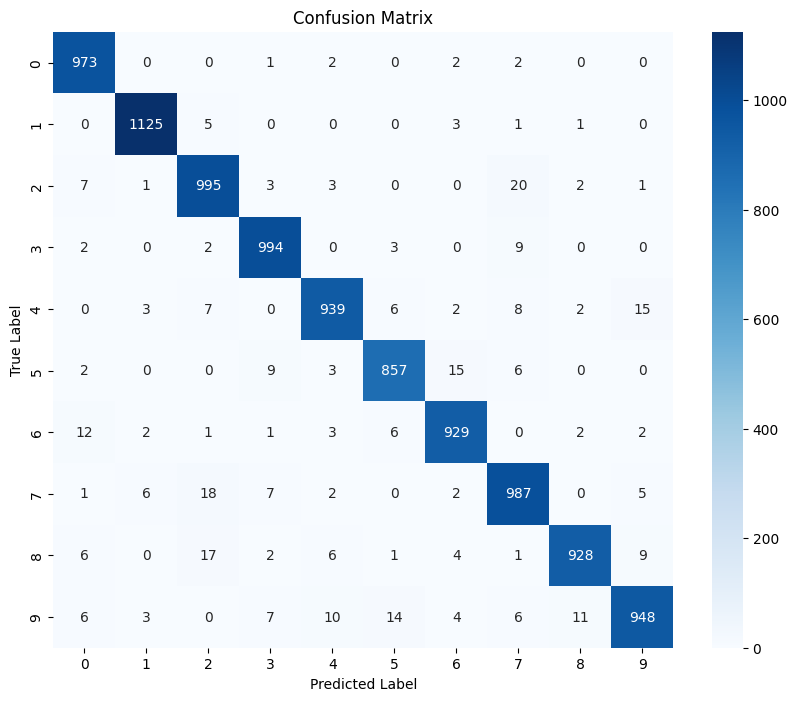

In [11]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

In [15]:
model.eval()
results_cls = torch.zeros(10)

absolute_errors = torch.tensor([0.0 for _ in range(10)])
no_digits = torch.tensor([0 for _ in range(10)])

with torch.no_grad():
    for data, (target_digit, target_angle) in test_loader:
        data = data.to(device)
        target_digit, target_angle = target_digit.to(device), target_angle.to(device)
        log_probs, angle = model(data)

        for i in range(10):
            mask = (target_digit == i)
            abs_error = torch.abs(target_angle[mask] - angle[mask])
            absolute_errors[i] += torch.sum(abs_error).cpu()
            no_digits += torch.sum(mask).cpu()

In [16]:
absolute_errors / no_digits

tensor([1.1240, 1.0334, 0.9960, 0.7778, 0.9176, 0.8672, 0.9726, 0.8242, 0.8738,
        0.9218])